In [9]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd()))

from scipy.spatial import ConvexHull
from algorithm.vertexModelBubbles import blend_projected_points, project_points_to_ellipsoid
from algorithm.vertexModel import add_faces_and_vertices_to_x, create_tetrahedra


In [2]:
def generate_ellipsoid(axes, centre=np.array([0.0, 0.0, 0.0]), n_u=50, n_v=25):
    """
    Generate x, y, z surface coordinates for plotting an ellipsoid.
    """

    u = np.linspace(0, 2 * np.pi, n_u)
    v = np.linspace(0, np.pi, n_v)

    x = axes[0] * np.outer(np.cos(u), np.sin(v)) + centre[0]
    y = axes[1] * np.outer(np.sin(u), np.sin(v)) + centre[1]
    z = axes[2] * np.outer(np.ones_like(u), np.cos(v)) + centre[2]

    return x, y, z


#def generate_surface_directions(n_points=16):
 #   """
 #   Generate approximately even radial directions on a unit sphere using equal-area
 #   latitude rings.
 #   """

 #   directions = []
 #   total_area = 4 * np.pi
 #   area_per_point = total_area / n_points
 #   distance = np.sqrt(area_per_point)
 #   M_theta = max(1, int(round(np.pi / distance)))
 #   d_theta = np.pi / M_theta
 #   d_phi = area_per_point / d_theta

 #   for m in range(M_theta):
 #       theta = np.pi * (m + 0.5) / M_theta
 #       M_phi = max(1, int(round(2 * np.pi * np.sin(theta) / d_phi)))

 #     for n in range(M_phi):
 #           phi = 2 * np.pi * n / M_phi
 #           x = np.sin(theta) * np.cos(phi)
 #           y = np.sin(theta) * np.sin(phi)
 #           z = np.cos(theta)
 #           directions.append([x, y, z])

 #   directions = np.array(directions)
 #   return directions[:n_points]


#def generate_ellipsoid_surface_points(n_points, axes, centre=np.array([0.0, 0.0, 0.0])):
 #   """
  #  Create point seeds directly on an ellipsoid surface.
  #  """
  #  centre = np.asarray(centre, dtype=float)
  #  directions = generate_surface_directions(n_points)
  #  return project_points_to_ellipsoid(directions, axes, centre)


#def generate_ellipsoid_surface_points(n_points, axes, centre=np.array([0.0, 0.0, 0.0]), relax=True, n_iter=150):
 #   """
  #  Create point seeds directly on an ellipsoid surface.
   # If relax=True, applies Thomson/Lloyd-style relaxation for even spacing.
   # """
   # centre = np.asarray(centre, dtype=float)
   # directions = generate_surface_directions(n_points)
   # points = project_points_to_ellipsoid(directions, axes, centre)

#    if relax:
  #      points = relax_points_on_ellipsoid(points, axes, center=centre, n_iter=n_iter)

 #   return points


def relax_points_on_ellipsoid(points, axes, center=np.zeros(3), n_iter=100, step_size=0.15):
    """
    Thomson-style relaxation of points constrained to an ellipsoid surface.

    Generalizes the repo's relax_points() (unit-sphere-only, Delaunay-centroid
    based) in two ways:
      1. Uses pairwise repulsive forces (Thomson problem electrostatics) instead
         of moving points toward Delaunay-triangle centroids.
      2. Projects the force onto the local tangent plane via (I - n n^T), then
         reprojects onto the TRUE ellipsoid surface (not a unit-sphere norm),
         so relaxation respects the real (a, b, c) geometry.
    """
    axes = np.asarray(axes, dtype=float)
    center = np.asarray(center, dtype=float)
    pts = points.copy()

    for it in range(n_iter):
        # Pairwise Coulomb-like repulsion
        diffs = pts[:, None, :] - pts[None, :, :]
        dists = np.linalg.norm(diffs, axis=-1)
        np.fill_diagonal(dists, np.inf)
        weights = 1.0 / (dists ** 2)
        force = np.sum(diffs * weights[:, :, None], axis=1)

        # Local surface normal = gradient of ellipsoid implicit function (x/a²,y/b²,z/c²)
        rel = pts - center
        normal = rel / axes**2
        normal /= np.linalg.norm(normal, axis=1, keepdims=True)

        # Tangent-plane projection operator (I - n n^T): keep only tangential force
        normal_component = np.sum(force * normal, axis=1, keepdims=True) * normal
        tangential_force = force - normal_component
        tangential_force /= np.linalg.norm(tangential_force, axis=1, keepdims=True).clip(min=1e-9)

        current_step = step_size * (1 - it / n_iter)  # anneal toward equilibrium
        pts = pts + current_step * tangential_force

        # Reproject onto the TRUE ellipsoid surface (generalizes the old unit-sphere norm)
        rel = pts - center
        norm_axes = np.linalg.norm(rel / axes, axis=1, keepdims=True)
        pts = center + rel / np.maximum(norm_axes, 1e-12)

    return pts



def place_cyst_seeds(
    n_points=16,
    center=np.array([0.0, 0.0, 0.0]),
    inner_axes=np.array([4.0, 3.0, 2.5]),
    outer_axes=np.array([6.0, 4.5, 3.5]),
    alpha=0.5,
    max_step=None,
):
    centre = np.asarray(center, dtype=float)

    outer_points = generate_ellipsoid_surface_points(
        n_points,
        outer_axes,
        centre,
    )

    inner_points = project_points_to_ellipsoid(
        outer_points,
        inner_axes,
        centre,
    )

    epithelial_points = blend_projected_points(
        outer_points,
        inner_points,
        alpha,
        max_step=max_step,
    )

    return {
        "outer_points": outer_points,
        "inner_points": inner_points,
        "epithelial_points": epithelial_points,
    }


def plot_cyst_seed_layout(
    result,
    center=np.array([0.0, 0.0, 0.0]),
    inner_axes=np.array([4.0, 3.0, 2.5]),
    outer_axes=np.array([8.0, 4.0, 3]),
):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    inner_x, inner_y, inner_z = generate_ellipsoid(inner_axes, centre=center)
    outer_x, outer_y, outer_z = generate_ellipsoid(outer_axes, centre=center)

    ax.plot_surface(inner_x, inner_y, inner_z, color='none', edgecolor='tab:blue', linewidth=0.1, alpha=0.05)
    ax.plot_surface(outer_x, outer_y, outer_z, color='none', edgecolor='tab:orange', linewidth=0.1, alpha=0.05)

    ax.scatter(*center, color='black', s=80, label='lumen centre')
    ax.scatter(*result['inner_points'].T, color='tab:blue', s=40, label='inner/lumen points')
    ax.scatter(*result['outer_points'].T, color='tab:orange', s=40, label='outer points')
    ax.scatter(*result['epithelial_points'].T, color='tab:green', s=70, label='epithelial cell centres')

    for i in range(len(result['inner_points'])):
        ax.plot(
            [result['inner_points'][i, 0], result['outer_points'][i, 0]],
            [result['inner_points'][i, 1], result['outer_points'][i, 1]],
            [result['inner_points'][i, 2], result['outer_points'][i, 2]],
            color='gray',
            alpha=0.8,
            linewidth=0.9,
        )

    ax.set_title('Ellipsoid-based cyst')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


In [3]:
from scipy.spatial import cKDTree

def check_spacing_uniformity(points, label=""):
    tree = cKDTree(points)
    dists, _ = tree.query(points, k=2)
    nn = dists[:, 1]
    print(f"{label}: mean={nn.mean():.3f}, std={nn.std():.3f}, CV={nn.std()/nn.mean():.3f}")

In [4]:
def _set_axes_equal_3d(ax):
    """Set equal aspect ratio on a 3D matplotlib axis."""
    limits = np.array([ax.get_xlim3d(), ax.get_ylim3d(), ax.get_zlim3d()])
    center = limits.mean(axis=1)
    radius = 0.5 * np.max(limits[:, 1] - limits[:, 0])
    ax.set_xlim3d([center[0] - radius, center[0] + radius])
    ax.set_ylim3d([center[1] - radius, center[1] + radius])
    ax.set_zlim3d([center[2] - radius, center[2] + radius])


#def plot_surface_topology(topology, points, ax=None, color='gray', alpha=0.6, linewidth=0.7):
 #   """
 #   Plot the convex-hull triangulation of per-cell surface points.

 #   `points` must be ordered by cell ID: row i corresponds to cell i + 1.
 #   """
 #   if ax is None:
 #       fig = plt.figure(figsize=(8, 8))
 #       ax = fig.add_subplot(111, projection='3d')
#
 #   for tri in topology['triangles_connectivity']:
 #       tri_pts = points[tri - 1]
 #       tri_loop = np.vstack((tri_pts, tri_pts[0]))
 #       ax.plot(tri_loop[:, 0], tri_loop[:, 1], tri_loop[:, 2], color=color, alpha=alpha, linewidth=linewidth)

 #   return ax


def plot_cyst_mesh(
    mesh,
    ax=None,
    show_apical=True,
    show_basal=True,
    show_lateral=True,
    show_cell_centers=False,
    apical_color='tab:blue',
    basal_color='tab:orange',
    lateral_color='gray',
    alpha=0.8,
    linewidth=0.6,
):
    """
    Plot the apical/basal surface wireframe and lateral edges of a cyst mesh.
    """
    if ax is None:
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')
        standalone = True
    else:
        standalone = False

    topology = mesh['topology']
    apical_vertices = mesh['apical_vertices']
    basal_vertices = mesh['basal_vertices']

    for cell_edges in topology['cell_edges']:
        for v1, v2 in cell_edges:
            if show_apical:
                ax.plot(
                    [apical_vertices[v1, 0], apical_vertices[v2, 0]],
                    [apical_vertices[v1, 1], apical_vertices[v2, 1]],
                    [apical_vertices[v1, 2], apical_vertices[v2, 2]],
                    color=apical_color,
                    alpha=alpha,
                    linewidth=linewidth,
                )
            if show_basal:
                ax.plot(
                    [basal_vertices[v1, 0], basal_vertices[v2, 0]],
                    [basal_vertices[v1, 1], basal_vertices[v2, 1]],
                    [basal_vertices[v1, 2], basal_vertices[v2, 2]],
                    color=basal_color,
                    alpha=alpha,
                    linewidth=linewidth,
                )

    if show_lateral:
        for v_idx in range(len(apical_vertices)):
            ax.plot(
                [apical_vertices[v_idx, 0], basal_vertices[v_idx, 0]],
                [apical_vertices[v_idx, 1], basal_vertices[v_idx, 1]],
                [apical_vertices[v_idx, 2], basal_vertices[v_idx, 2]],
                color=lateral_color,
                alpha=0.35,
                linewidth=0.4,
            )

    if show_cell_centers:
        n_cells = len(topology['main_cells'])
        centers = mesh['X'][1:n_cells + 1]
        ax.scatter(
            centers[:, 0],
            centers[:, 1],
            centers[:, 2],
            color='tab:green',
            s=12,
            alpha=0.7,
            label='cell centres',
        )

    ax.set_title('Cyst epithelial mesh')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    _set_axes_equal_3d(ax)

    if standalone:
        plt.tight_layout()
        plt.show()

    return ax

In [5]:

def create_2d_surface_topology(points, center=np.array([0.0, 0.0, 0.0])):
    """
    Create surface topology from a point cloud that shares one radial layout.

    Typically `points` are unit directions from the origin; the same topology
    is then reused for inner, outer, and epithelial layers obtained by radial
    projection onto different ellipsoids.

    Cell IDs are 1..N.
    Each row in triangles_connectivity is a topological vertex:
    [cell_a, cell_b, cell_c].
    """
    points = np.asarray(points, dtype=float)
    center = np.asarray(center, dtype=float)
    n_cells = points.shape[0]
    main_cells = np.arange(1, n_cells + 1)

    hull = ConvexHull(points)

    # Convert ConvexHull's 0-based point indices to cell IDs 1..N.
    triangles_connectivity = hull.simplices.astype(int) + 1

    neighbour_edges = []
    for tri in triangles_connectivity:
        neighbour_edges.extend([
            sorted([tri[0], tri[1]]),
            sorted([tri[1], tri[2]]),
            sorted([tri[2], tri[0]]),
        ])
    neighbours_network = np.unique(np.asarray(neighbour_edges, dtype=int), axis=0)

    # Radial directions from the center to each seed point.
    cell_dirs = points - center
    cell_dirs /= np.linalg.norm(cell_dirs, axis=1, keepdims=True)

    vertex_seed_dirs = points[triangles_connectivity - 1].mean(axis=1) - center
    vertex_seed_dirs /= np.linalg.norm(vertex_seed_dirs, axis=1, keepdims=True)

    cell_edges = []
    for cell_id in main_cells:
        vertex_ids = np.where(np.any(triangles_connectivity == cell_id, axis=1))[0]

        radial = cell_dirs[cell_id - 1]
        local_dirs = vertex_seed_dirs[vertex_ids]

        tangent_a = np.cross(radial, np.array([0.0, 0.0, 1.0]))
        if np.linalg.norm(tangent_a) < 1e-8:
            tangent_a = np.cross(radial, np.array([0.0, 1.0, 0.0]))
        tangent_a /= np.linalg.norm(tangent_a)
        tangent_b = np.cross(radial, tangent_a)

        rel = local_dirs - radial
        angles = np.arctan2(rel @ tangent_b, rel @ tangent_a)
        ordered_vertex_ids = vertex_ids[np.argsort(angles)]

        cell_edges.append(
            np.column_stack([
                ordered_vertex_ids,
                np.roll(ordered_vertex_ids, -1),
            ])
        )

    return {
        "main_cells": main_cells,
        "triangles_connectivity": triangles_connectivity,
        "neighbours_network": neighbours_network,
        "cell_edges": cell_edges,
        "vertex_seed_dirs": vertex_seed_dirs,
    }


def build_cyst_mesh(result, center, inner_axes, outer_axes):
    """
    Build a cyst mesh using one shared topology derived from radial directions.

    Inner, outer, and epithelial layers all use the same connectivity; only the
    radial projection differs between apical and basal surfaces.
    """
    center = np.asarray(center, dtype=float)
    inner_axes = np.asarray(inner_axes, dtype=float)
    outer_axes = np.asarray(outer_axes, dtype=float)

    # Use the actual ellipsoid surface positions for topology so seed spacing
    # follows the deformed ellipsoid geometry rather than the original sphere.
    topology = create_2d_surface_topology(result["outer_points"], center=np.zeros(3))

    n_cells = len(topology["main_cells"])

    # X index 0 is unused because cell IDs start at 1.
    X = np.zeros((n_cells + 1, 3))
    X[1:] = result["epithelial_points"]

    apical_vertices = project_points_to_ellipsoid(
        topology["vertex_seed_dirs"],
        inner_axes,
        center,
    )

    basal_vertices = project_points_to_ellipsoid(
        topology["vertex_seed_dirs"],
        outer_axes,
        center,
    )

    X, apical_face_ids, Xg_apical, apical_vertex_ids = add_faces_and_vertices_to_x(
        X,
        result["inner_points"],
        apical_vertices,
    )

    Twg_apical = create_tetrahedra(
        topology["triangles_connectivity"],
        topology["neighbours_network"],
        topology["cell_edges"],
        topology["main_cells"],
        apical_face_ids,
        apical_vertex_ids,
    )

    X, basal_face_ids, Xg_basal, basal_vertex_ids = add_faces_and_vertices_to_x(
        X,
        result["outer_points"],
        basal_vertices,
    )

    Twg_basal = create_tetrahedra(
        topology["triangles_connectivity"],
        topology["neighbours_network"],
        topology["cell_edges"],
        topology["main_cells"],
        basal_face_ids,
        basal_vertex_ids,
    )

    Twg_lumen = np.column_stack([
        np.zeros(topology["triangles_connectivity"].shape[0], dtype=int),
        topology["triangles_connectivity"],
    ])
    Twg = np.vstack([Twg_lumen, Twg_apical, Twg_basal])

    return {
        "X": X,
        "Twg": Twg,
        "lumen_cell": 0,
        "topology": topology,
        "main_cells_with_lumen": np.concatenate([[0], topology["main_cells"]]),
        "apical_face_ids": apical_face_ids,
        "basal_face_ids": basal_face_ids,
        "apical_vertex_ids": apical_vertex_ids,
        "basal_vertex_ids": basal_vertex_ids,
        "Xg_apical": Xg_apical,
        "Xg_basal": Xg_basal,
        "apical_vertices": apical_vertices,
        "basal_vertices": basal_vertices,
    }

In [6]:
#TESTING RANGE CODE FROM REPO (Based on https://github.com/RANGE-kit/RANGE)


def generate_micelle_ellipsoid_points(
    n_points,
    axes,
    centre=np.array([0.0, 0.0, 0.0]),
):
    """
    Generate exactly n_points approximately uniformly distributed on an ellipsoid.

    This is a cyst-adapted version of the RANGE micelle idea:
    - points are placed on an ellipsoid defined by axes (a, b, c)
    - outward normals are computed from the ellipsoid implicit surface

    Unlike the original RANGE micelle grid, this version returns exactly n_points,
    which is better for cell-centre initialisation.
    """

    axes = np.asarray(axes, dtype=float)
    centre = np.asarray(centre, dtype=float)
    a, b, c = axes

    # Fibonacci directions on a unit sphere
    i = np.arange(n_points)
    golden_angle = np.pi * (3.0 - np.sqrt(5.0))

    y = 1.0 - 2.0 * (i + 0.5) / n_points
    r = np.sqrt(1.0 - y**2)
    phi = i * golden_angle

    # Converts the spiral positions into 3D points on the unit sphere
    x_s = r * np.cos(phi)
    y_s = y
    z_s = r * np.sin(phi)

    # Parametric equations for ellipsoid surface points
    points = np.column_stack([
        centre[0] + a * x_s,
        centre[1] + b * y_s,
        centre[2] + c * z_s,
    ])

    # Compute normals via gradient of implicit function
    nx = (points[:, 0] - centre[0]) / (a * a)
    ny = (points[:, 1] - centre[1]) / (b * b)
    nz = (points[:, 2] - centre[2]) / (c * c)

    # Normalize normals & Stack points and normals
    normals = np.column_stack([nx, ny, nz])
    normals /= np.linalg.norm(normals, axis=1)[:, None]

    return points, normals


def generate_ellipsoid_surface_points(
    n_points,
    axes,
    centre=np.array([0.0, 0.0, 0.0]),
    relax=False,
    n_iter=150,
):
    """
    Generate ellipsoid surface points for cyst seeding.

    Replacement version:
    - uses micelle/Thomson-style ellipsoid placement
    - returns exactly n_points
    - optionally applies your existing ellipsoid repulsion relaxation
    """

    points, normals = generate_micelle_ellipsoid_points(
        n_points=n_points,
        axes=axes,
        centre=centre,
    )

    if relax: #currently broken
        points = relax_points_on_ellipsoid(
            points,
            axes,
            center=centre,
            n_iter=n_iter,
        )

        # Recompute normals after relaxation
        axes = np.asarray(axes, dtype=float)
        centre = np.asarray(centre, dtype=float)
        a, b, c = axes

        nx = (points[:, 0] - centre[0]) / (a * a)
        ny = (points[:, 1] - centre[1]) / (b * b)
        nz = (points[:, 2] - centre[2]) / (c * c)

        normals = np.column_stack([nx, ny, nz])
        normals /= np.linalg.norm(normals, axis=1)[:, None]

    return points

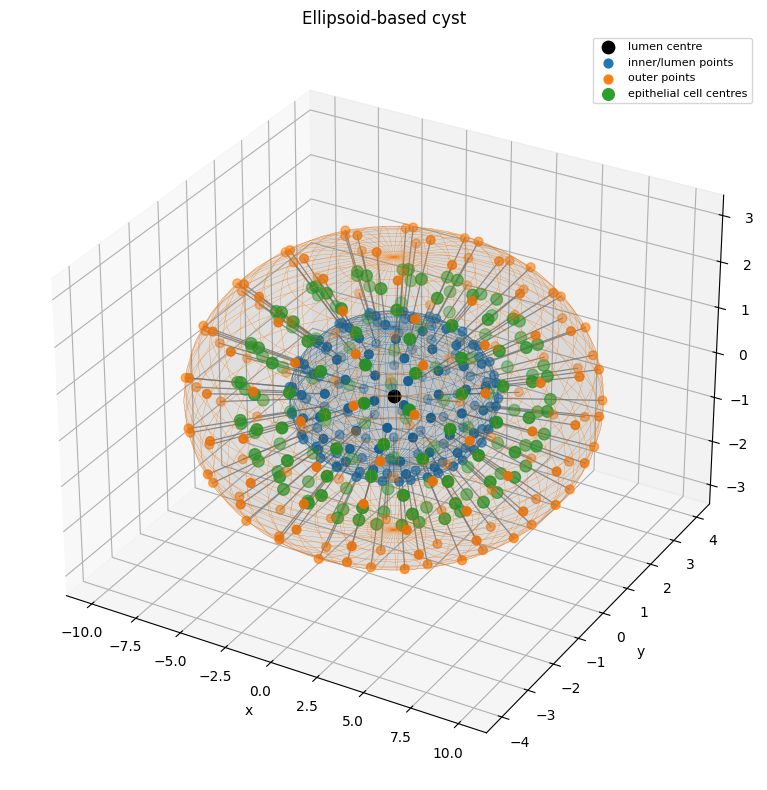

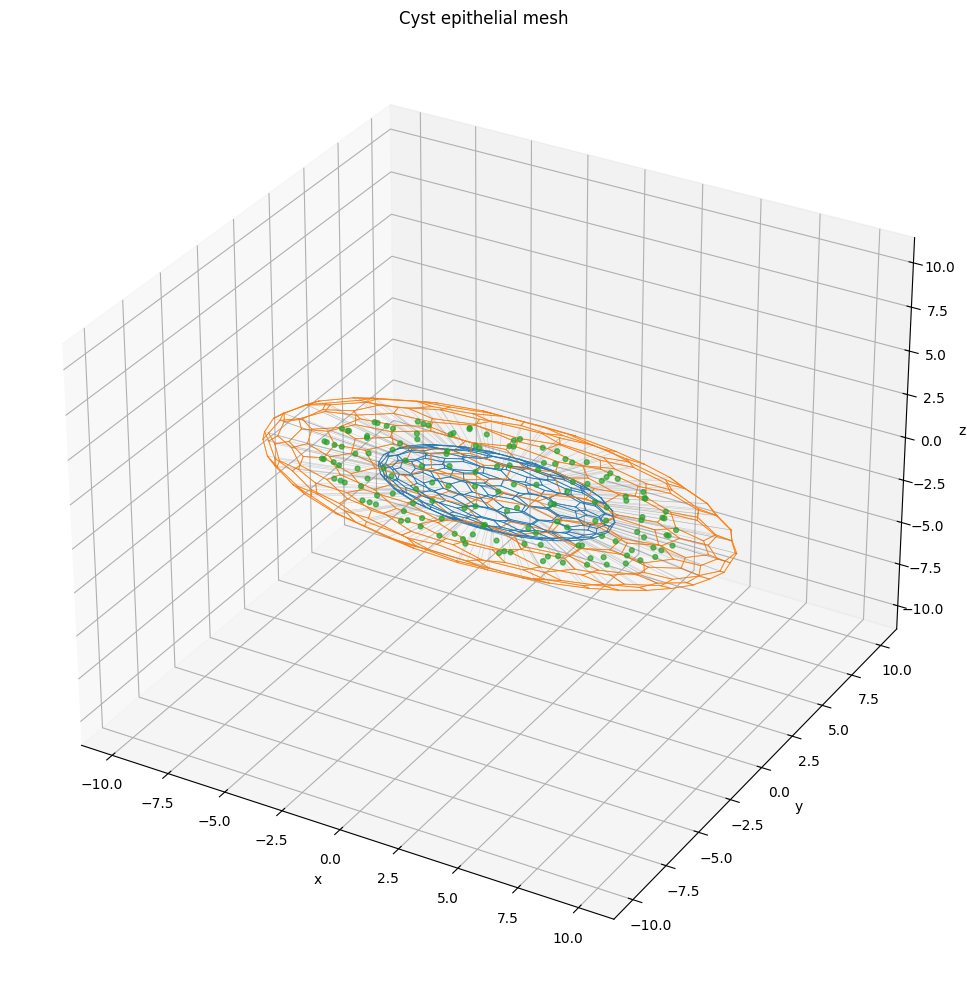

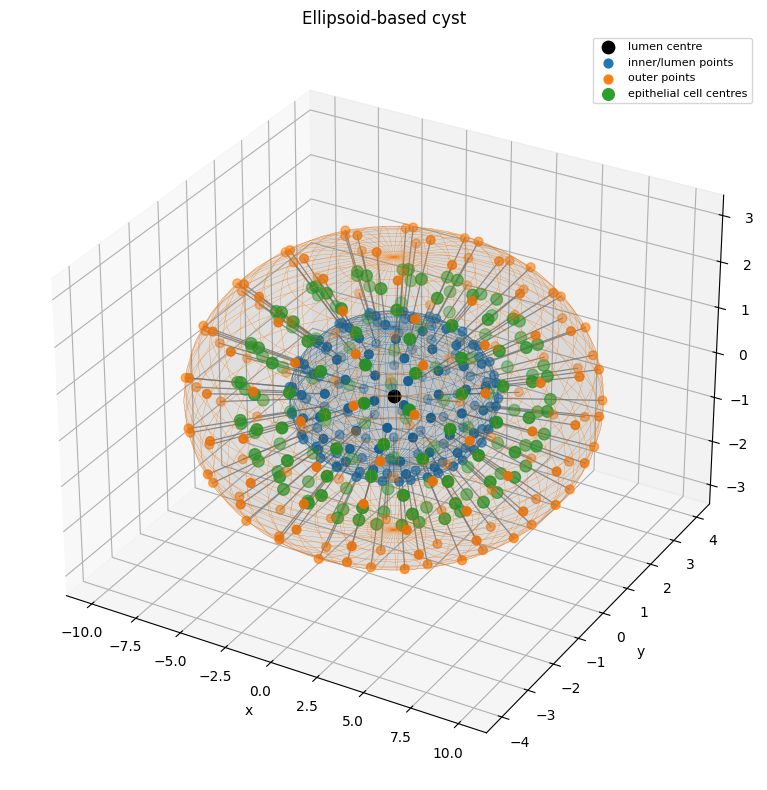

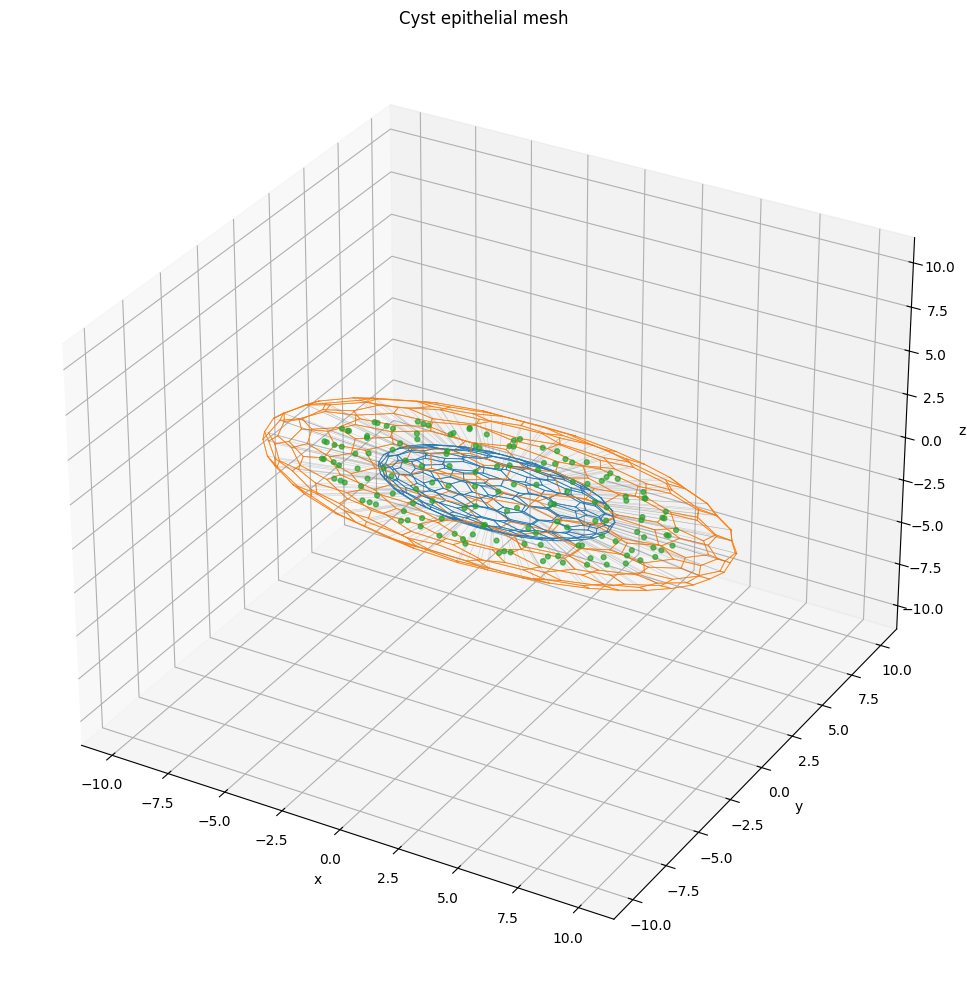

<Axes3D: title={'center': 'Cyst epithelial mesh'}, xlabel='x', ylabel='y', zlabel='z'>

In [10]:
center = np.array([0.0, 0.0, 0.0])
inner_axes = np.array([5.0, 2.0, 1.5])
outer_axes = np.array([10.0, 4.0, 3.0])

result = place_cyst_seeds(
    n_points=150,
    center=center,
    inner_axes=inner_axes,
    outer_axes=outer_axes,
    alpha=0.5,
)

mesh = build_cyst_mesh(result, center, inner_axes, outer_axes)
plot_cyst_seed_layout(result, center=center, inner_axes=inner_axes, outer_axes=outer_axes)
plot_cyst_mesh(mesh, show_cell_centers=True)

In [8]:
check_spacing_uniformity(result["outer_points"], "outer (relaxed)")

outer (relaxed): mean=1.198, std=0.231, CV=0.193


In [11]:
print(build_cyst_mesh(result, center, inner_axes, outer_axes)["Twg"])

[[100 121 108 301]
 [129 121 108 302]
 [112 104 125 303]
 ...
 [148 149 783 784]
 [148 150 783 945]
 [149 150 750 783]]


In [22]:
pip install trame


  Using cached trame_client-3.13.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached trame_common-1.2.4-py3-none-any.whl.metadata (4.3 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
Using cached trame_client-3.13.2-py3-none-any.whl (251 kB)
Using cached trame_common-1.2.4-py3-none-any.whl (23 kB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)

   ------- --------------------------------  3/16 [msgpack]
   --------------- ------------------------  6/16 [attrs]
   ---------------------- -----------------  9/16 [yarl]
   ------------------------- -------------- 10/16 [trame-client]
   ------------------------------ --------- 12/16 [aiohttp]
   ------------------------------ --------- 12/16 [aiohttp]
   -------------------------------- ------- 13/16 [wslink]
   ----------------------------------- ---- 14/16 [trame-server]
   ----------------------

INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 0
INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 1
INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 2
INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 3
INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 4
INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 5
INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 6
INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 7
INFO [2026/07/09 01:23:59 PM] pyVertexModel: Building cell 8
INFO [2026/07/09 01:24:00 PM] pyVertexModel: Building cell 9
INFO [2026/07/09 01:24:00 PM] pyVertexModel: Building cell 10
INFO [2026/07/09 01:24:00 PM] pyVertexModel: Building cell 11
INFO [2026/07/09 01:24:00 PM] pyVertexModel: Building cell 12
INFO [2026/07/09 01:24:00 PM] pyVertexModel: Building cell 13
INFO [2026/07/09 01:24:00 PM] pyVertexModel: Building cell 14
INFO [2026/07/09 01:24:00 PM] pyVertexModel: Building cell 15
INFO [2026/07/09 0

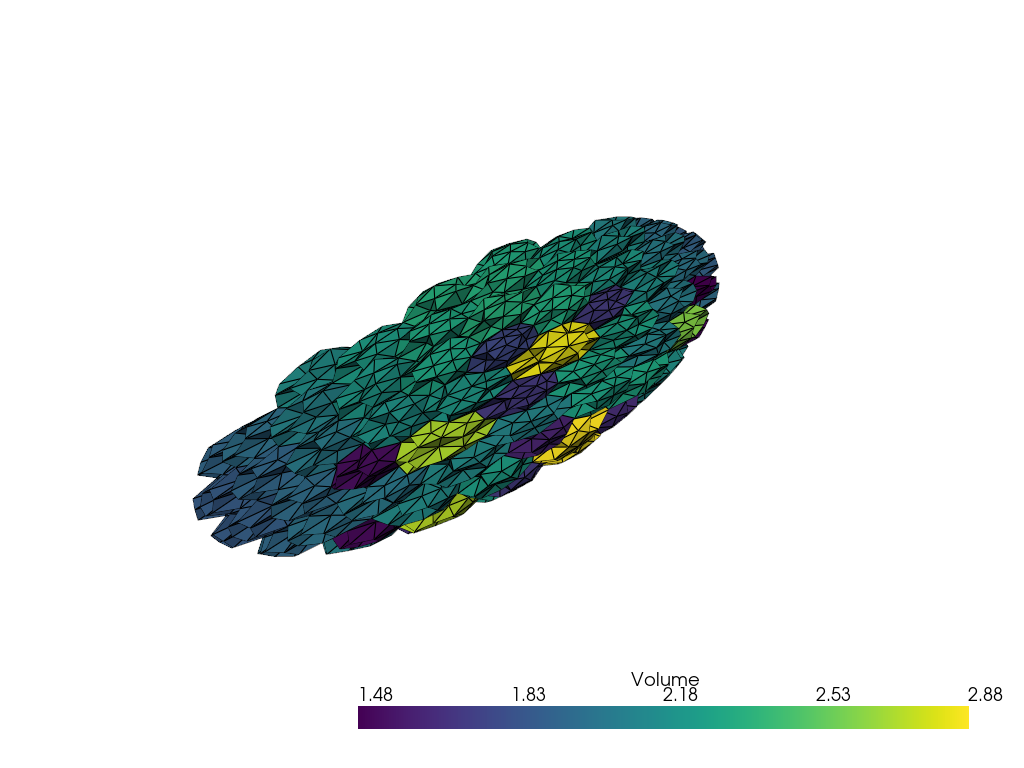

In [11]:

from pyVertexModel.geometry.geo import Geo
from pyVertexModel.parameters.set import Set
import numpy as np

c_set = Set()
c_set.cyst_scratch()
c_set.update_derived_parameters()

geo = Geo()
geo.nCells = len(mesh["main_cells_with_lumen"])
c_set.TotalCells = geo.nCells
geo.Main_cells = range(geo.nCells)

geo.XgBottom = [mesh["lumen_cell"]]
geo.XgTop = np.concatenate([mesh["Xg_apical"], mesh["Xg_basal"]])
geo.XgID = np.append(geo.XgTop, mesh["lumen_cell"])

geo.XgLumen = np.array([mesh["lumen_cell"]])
geo.XgApical = mesh["Xg_apical"]
geo.XgBasal = mesh["Xg_basal"]

geo.build_cells(c_set, mesh["X"], mesh["Twg"])

# Render using the repo's own machinery — this is EXACTLY what the real pipeline produces
import pyvista as pv
try:
    plotter = pv.Plotter(off_screen=True)
except Exception:
    plotter = pv.Plotter()
for c_cell in geo.Cells[1:100]:
    if c_cell.AliveStatus is not None:
        plotter.add_mesh(c_cell.create_pyvista_mesh(), show_edges=True)
plotter.show()